In [10]:
from sklearn.datasets import load_breast_cancer

data=load_breast_cancer()
x=data.data
y=data.target

print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [12]:
#training a logistic regression model with original data

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_original = LogisticRegression(max_iter=1000)
model_original.fit(x_train,y_train)
y_pred_original= model_original.predict(x_test)

acc_original=accuracy_score(y_pred_original,y_test)
print("Accuracy score with original dataset=",acc_original)

Accuracy score with original dataset= 0.9736842105263158


In [13]:
#applying PCA
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
x_train_pca= pca.fit_transform(x_train)
x_test_pca= pca.transform(x_test)

print("After PCA:")
print("x_train shape",x_test_pca.shape)
print("x_test shape",x_test_pca.shape)

After PCA:
x_train shape (114, 2)
x_test shape (114, 2)


In [15]:
#Explained variance

variance= pca.explained_variance_ratio_
print("Explained Variance of PC1:",variance[0])
print("Explained Variance of PC2:",variance[1])

print("Total variance retained:",variance.sum())

Explained Variance of PC1: 0.4350278158333762
Explained Variance of PC2: 0.1950000688520273
Total variance retained: 0.6300278846854035


In [16]:
# new logistic regression model after pca

model=LogisticRegression(max_iter=1000)
model.fit(x_train_pca,y_train)
y_pred_pca=model.predict(x_test_pca)

print("Accuracy after PCA:",accuracy_score(y_pred_pca,y_test))

Accuracy after PCA: 0.9912280701754386


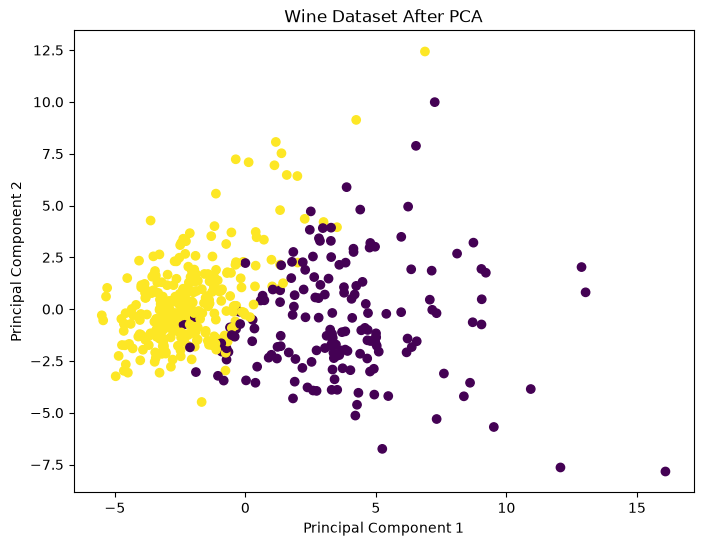

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    x_train_pca[:, 0],
    x_train_pca[:, 1],
    c=y_train,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset After PCA")
plt.show()